In [6]:
import numpy as np
import scipy.stats as stats
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import os
import random
from dynamic_routing_analysis import decoding_utils

import matplotlib
import matplotlib.font_manager as fm

matplotlib.rcParams['font.size'] = 8
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
fm.FontProperties().set_family('arial')

%load_ext autoreload
%autoreload 2
%matplotlib inline
# %matplotlib widget
# %matplotlib notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
baseline_decoder_path=r"D:\decoding_results_from_CO\task_vs_spont_2026-04-22\task_predict_proba_by_session_10_units.parquet"
vis_target_decoder_path=r"D:\decoding_results_from_CO\baseline_vis_target_aud_target_context_2026-04-22\vis_target_baseline_subtract_10_units_predict_proba_per_session_structure_with_unit_ids.parquet"
aud_target_decoder_path=r"D:\decoding_results_from_CO\baseline_vis_target_aud_target_context_2026-04-22\aud_target_baseline_subtract_10_units_predict_proba_per_session_structure_with_unit_ids.parquet"

In [105]:
baseline_decoder_results=pd.read_parquet(baseline_decoder_path)
vis_target_decoder_results=pd.read_parquet(vis_target_decoder_path)
aud_target_decoder_results=pd.read_parquet(aud_target_decoder_path)

In [4]:
session_table_path=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\session_table_v0.272.parquet"
session_table=pl.read_parquet(session_table_path)

dr_session_list=(
    session_table.filter(
    pl.col('project')=="DynamicRouting",
    pl.col('is_production'),
    pl.col('is_annotated'),
    pl.col('issues')==[],
    # pl.col('is_good_behavior').eq(True),
    )['session_id'].to_list()
    )

In [49]:
### get updated session list (2 aud 2 vis blocks dprime>1) -- make new function!
all_performance=pl.scan_parquet('s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.272/consolidated/performance.parquet').collect()
all_trials=pl.scan_parquet('s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.272/consolidated/trials.parquet').collect()

dr_session_performance={
    'session_id':[],
    'session_table_is_good_behavior':[],
    'performance_is_good_behavior':[],
    '_2vis_2aud_is_good_behavior':[],
    '_2vis_2aud_is_okay_behavior':[],
}
for sel_session in all_performance['session_id'].unique():

    temp_project=session_table.filter(pl.col('session_id')==sel_session)['project']
    if len(temp_project)==0 or temp_project[0] not in ["DynamicRouting"]:
        continue

    session_performance=all_performance.filter(pl.col('session_id')==sel_session)
    n_passing_blocks=np.nansum(session_performance['cross_modality_dprime'].to_numpy()>=1.0)
    n_engaged_blocks=np.nansum(session_performance['n_contingent_rewards'].to_numpy()>10)

    n_vis_passing_blocks=np.nansum(session_performance.filter(pl.col('rewarded_modality')=='vis')['cross_modality_dprime'].to_numpy()>=1.0)
    n_aud_passing_blocks=np.nansum(session_performance.filter(pl.col('rewarded_modality')=='aud')['cross_modality_dprime'].to_numpy()>=1.0)

    n_vis_okay_blocks=np.nansum(session_performance.filter(pl.col('rewarded_modality')=='vis')['cross_modality_dprime'].to_numpy()>=0.5)
    n_aud_okay_blocks=np.nansum(session_performance.filter(pl.col('rewarded_modality')=='aud')['cross_modality_dprime'].to_numpy()>=0.5)

    dr_session_performance['session_id'].append(sel_session)

    dr_session_performance['session_table_is_good_behavior'].append(session_table.filter(pl.col('session_id')==sel_session)['is_good_behavior'][0])
    if n_passing_blocks>4 and n_engaged_blocks>4:
        dr_session_performance['performance_is_good_behavior'].append(True)
    else:
        dr_session_performance['performance_is_good_behavior'].append(False)

    if n_vis_passing_blocks>=2 and n_aud_passing_blocks>=2:
        dr_session_performance['_2vis_2aud_is_good_behavior'].append(True)
    else:
        dr_session_performance['_2vis_2aud_is_good_behavior'].append(False)

    if n_vis_okay_blocks>=2 and n_aud_okay_blocks>=2:
        dr_session_performance['_2vis_2aud_is_okay_behavior'].append(True)
    else:
        dr_session_performance['_2vis_2aud_is_okay_behavior'].append(False)

dr_session_performance=pl.DataFrame(dr_session_performance)
# dr_session_performance

dr_good_behavior_list=dr_session_performance.to_pandas().query('_2vis_2aud_is_good_behavior==True')['session_id'].values
# dr_good_behavior_list=dr_session_performance.to_pandas().query('_2vis_2aud_is_okay_behavior==True')['session_id'].values

In [116]:
vis_target_decoder_results['bin_center'].unique()

array([-0.075, -0.025,  0.025,  0.075,  0.125,  0.175,  0.225,  0.275,
        0.325,  0.375,  0.425,  0.475,  0.525,  0.575])

In [121]:
# sel_session="664851_2023-11-13"
sel_session='742903_2024-10-22'
# sel_session='626791_2022-08-15'
sel_structure="MOs"
sel_unit_subsample_size=10
sel_time_aligned_to='stim_start_time'

sel_baseline_bin_center=-0.25
sel_vis_bin_center=0.075
sel_aud_bin_center=0.075

correction='flip_aud' #'subtract_mean' or 'flip_aud' or 'none'
excl_instruction_trials=True
# unrewarded_targets_only=False
# post_informative_trials_only=False
# informative_trials_and_post=False
# targets_only=False


structure_baseline_results=decoding_utils.get_session_structure_results(
    baseline_decoder_results, sel_session, sel_structure, sel_unit_subsample_size, sel_time_aligned_to, sel_baseline_bin_center)
structure_vis_results=decoding_utils.get_session_structure_results(
    vis_target_decoder_results, sel_session, sel_structure, sel_unit_subsample_size, sel_time_aligned_to, sel_vis_bin_center)
structure_aud_results=decoding_utils.get_session_structure_results(
    aud_target_decoder_results, sel_session, sel_structure, sel_unit_subsample_size, sel_time_aligned_to, sel_aud_bin_center)

baseline_trial_indices=structure_baseline_results['trial_index'].values[0]
session_trials=all_trials.filter(pl.col('session_id').eq(sel_session)).sort('trial_index').to_pandas()
block_switches=session_trials.query('is_block_switch').index.values
baseline_trials=session_trials.query('trial_index in @baseline_trial_indices').copy().reset_index(drop=True)
baseline_predict_proba=structure_baseline_results['predict_proba'].values[0]

vis_trial_indices=structure_vis_results['trial_index'].values[0]
vis_trials=session_trials.query('trial_index in @vis_trial_indices').copy().reset_index(drop=True)
vis_predict_proba=structure_vis_results['predict_proba'].values[0]

aud_trial_indices=structure_aud_results['trial_index'].values[0]
aud_trials=session_trials.query('trial_index in @aud_trial_indices').copy().reset_index(drop=True)
aud_predict_proba=structure_aud_results['predict_proba'].values[0]

corrected_structure_baseline_results = []
corrected_structure_vis_results = []
corrected_structure_aud_results = []

for bb in session_trials['block_index'].unique():
    block_trials=session_trials.query(f'block_index=={bb}')
    baseline_block_trial_indices=baseline_trials.query(f'block_index=={bb}').index.values
    vis_block_trial_indices=vis_trials.query(f'block_index=={bb}').index.values
    aud_block_trial_indices=aud_trials.query(f'block_index=={bb}').index.values
    if correction=='flip_aud':
        if block_trials['rewarded_modality'].values[0]=='vis':
            corrected_structure_baseline_results.append(baseline_predict_proba[baseline_block_trial_indices])
            corrected_structure_vis_results.append(vis_predict_proba[vis_block_trial_indices])
            corrected_structure_aud_results.append(aud_predict_proba[aud_block_trial_indices])
        elif block_trials['rewarded_modality'].values[0]=='aud':
            corrected_structure_baseline_results.append(1 - baseline_predict_proba[baseline_block_trial_indices])
            corrected_structure_vis_results.append(1-vis_predict_proba[vis_block_trial_indices])
            corrected_structure_aud_results.append(1-aud_predict_proba[aud_block_trial_indices])
    elif correction=='subtract_mean':
        corrected_structure_baseline_results.append(baseline_predict_proba[baseline_block_trial_indices] - np.nanmean(baseline_predict_proba[baseline_block_trial_indices]))
        corrected_structure_vis_results.append(vis_predict_proba[vis_block_trial_indices] - np.nanmean(vis_predict_proba[vis_block_trial_indices]))
        corrected_structure_aud_results.append(aud_predict_proba[aud_block_trial_indices] - np.nanmean(aud_predict_proba[aud_block_trial_indices]))
    elif correction=='none':
        corrected_structure_baseline_results.append(baseline_predict_proba[baseline_block_trial_indices])
        corrected_structure_vis_results.append(vis_predict_proba[vis_block_trial_indices])
        corrected_structure_aud_results.append(aud_predict_proba[aud_block_trial_indices])

corrected_structure_baseline_results = np.concatenate(corrected_structure_baseline_results)
corrected_structure_vis_results = np.concatenate(corrected_structure_vis_results)
corrected_structure_aud_results = np.concatenate(corrected_structure_aud_results)

if excl_instruction_trials:
    baseline_instruction_trial_indices=baseline_trials.query('is_instruction').index.values
    vis_instruction_trial_indices=vis_trials.query('is_instruction').index.values
    aud_instruction_trial_indices=aud_trials.query('is_instruction').index.values

    corrected_structure_baseline_results[baseline_instruction_trial_indices]=np.nan
    corrected_structure_vis_results[vis_instruction_trial_indices]=np.nan
    corrected_structure_aud_results[aud_instruction_trial_indices]=np.nan

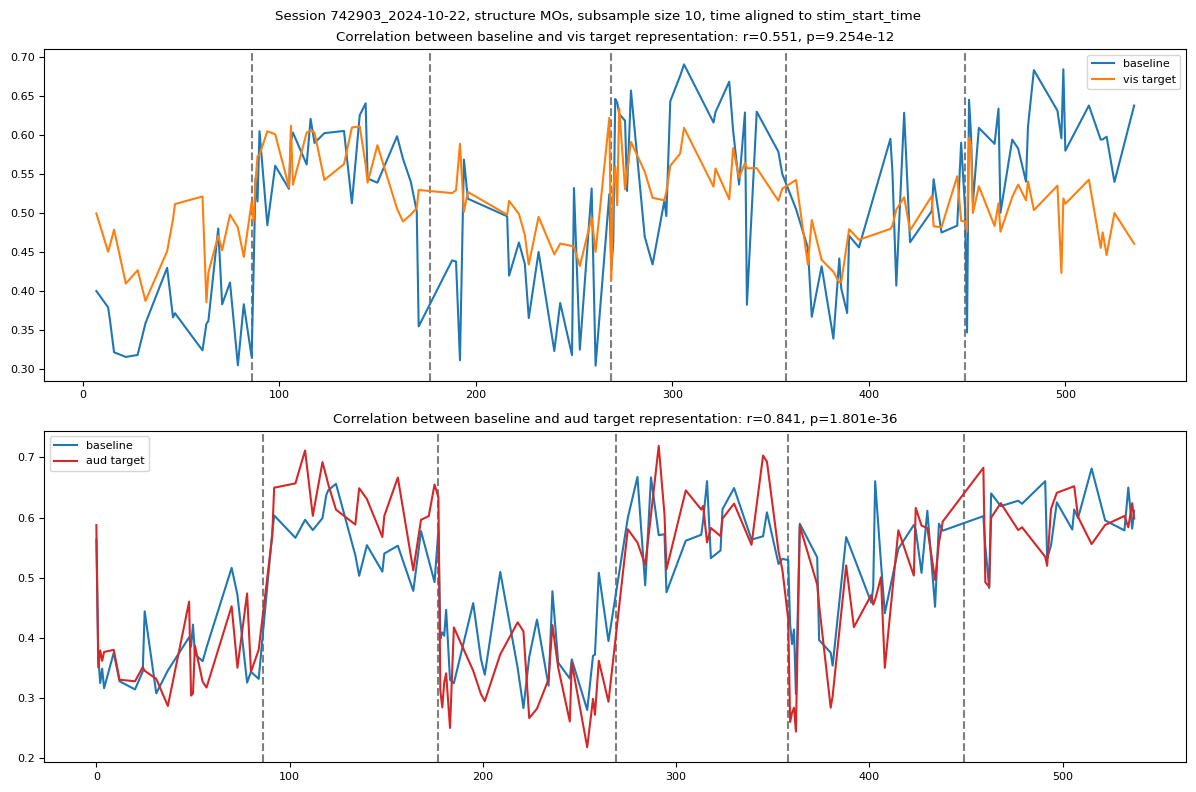

In [ ]:
fig,ax=plt.subplots(2,1,figsize=(12,8))

for bb in block_switches:
    ax[0].axvline(bb, color='k', linestyle='--', alpha=0.5)
    ax[1].axvline(bb, color='k', linestyle='--', alpha=0.5)


rbv,pbv=stats.pearsonr(structure_baseline_results['predict_proba'].values[0][structure_vis_results['trial_index'].values[0]], structure_vis_results['predict_proba'].values[0])
ax[0].plot(structure_baseline_results['trial_index'].values[0][structure_vis_results['trial_index'].values[0]], 
           structure_baseline_results['predict_proba'].values[0][structure_vis_results['trial_index'].values[0]], label='baseline')
ax[0].plot(structure_vis_results['trial_index'].values[0], structure_vis_results['predict_proba'].values[0], label='vis target')
ax[0].legend()
ax[0].set_title(f'Correlation between baseline and vis target representation: r={rbv:.3f}, p={pbv:.3e}')

rba,pba=stats.pearsonr(structure_baseline_results['predict_proba'].values[0][structure_aud_results['trial_index'].values[0]], structure_aud_results['predict_proba'].values[0])
ax[1].plot(structure_baseline_results['trial_index'].values[0][structure_aud_results['trial_index'].values[0]], 
           structure_baseline_results['predict_proba'].values[0][structure_aud_results['trial_index'].values[0]], label='baseline')
ax[1].plot(structure_aud_results['trial_index'].values[0], structure_aud_results['predict_proba'].values[0], label='aud target', color='tab:red')
ax[1].legend()
ax[1].set_title(f'Correlation between baseline and aud target representation: r={rba:.3f}, p={pba:.3e}')

fig.suptitle(f'Session {sel_session}, structure {sel_structure}, subsample size {sel_unit_subsample_size}, time aligned to {sel_time_aligned_to}')
fig.tight_layout()

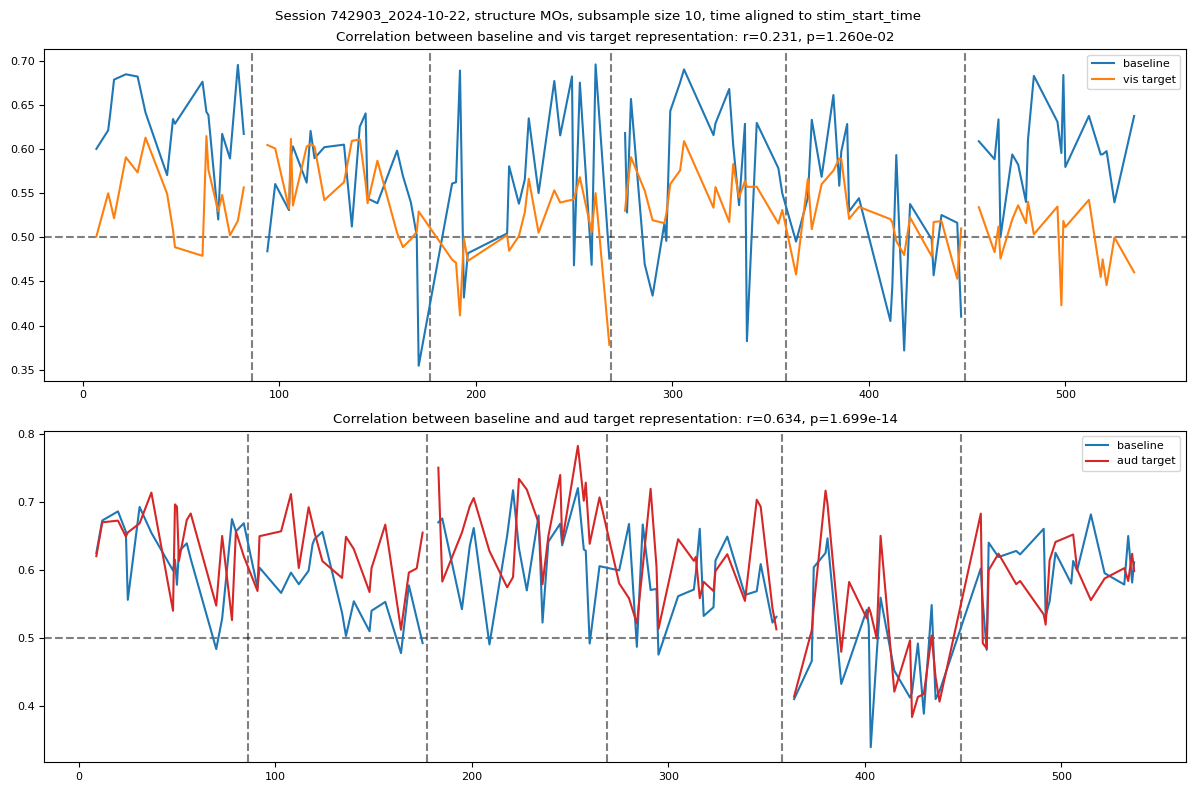

In [123]:
fig,ax=plt.subplots(2,1,figsize=(12,8))

for bb in block_switches:
    ax[0].axvline(bb, color='k', linestyle='--', alpha=0.5)
    ax[1].axvline(bb, color='k', linestyle='--', alpha=0.5)

ax[0].axhline(0.5, color='k', linestyle='--', alpha=0.5)
ax[1].axhline(0.5, color='k', linestyle='--', alpha=0.5)


rbv,pbv=stats.pearsonr(
    corrected_structure_baseline_results[structure_vis_results['trial_index'].values[0]][~np.isnan(corrected_structure_vis_results)], 
    corrected_structure_vis_results[~np.isnan(corrected_structure_vis_results)])
ax[0].plot(structure_baseline_results['trial_index'].values[0][structure_vis_results['trial_index'].values[0]], 
           corrected_structure_baseline_results[structure_vis_results['trial_index'].values[0]], label='baseline')
ax[0].plot(structure_vis_results['trial_index'].values[0], corrected_structure_vis_results, label='vis target')
ax[0].legend()
ax[0].set_title(f'Correlation between baseline and vis target representation: r={rbv:.3f}, p={pbv:.3e}')

rba,pba=stats.pearsonr(
    corrected_structure_baseline_results[structure_aud_results['trial_index'].values[0]][~np.isnan(corrected_structure_aud_results)], 
    corrected_structure_aud_results[~np.isnan(corrected_structure_aud_results)])
ax[1].plot(structure_baseline_results['trial_index'].values[0][structure_aud_results['trial_index'].values[0]], 
           corrected_structure_baseline_results[structure_aud_results['trial_index'].values[0]], label='baseline')
ax[1].plot(structure_aud_results['trial_index'].values[0], corrected_structure_aud_results, label='aud target', color='tab:red')
ax[1].legend()
ax[1].set_title(f'Correlation between baseline and aud target representation: r={rba:.3f}, p={pba:.3e}')

fig.suptitle(f'Session {sel_session}, structure {sel_structure}, subsample size {sel_unit_subsample_size}, time aligned to {sel_time_aligned_to}')
fig.tight_layout()

In [124]:
#for each session and structure, get the correlation between baseline and each stim target context representation

sel_unit_subsample_size=10
sel_time_aligned_to='stim_start_time'

sel_baseline_bin_center=-0.25
sel_vis_bin_center=0.075
sel_aud_bin_center=0.075

correction='flip_aud' #'subtract_mean' or 'flip_aud' or 'none'
excl_instruction_trials=True

baseline_stim_context_correlation_results={
    'session_id':[],
    'structure':[],
    'baseline_vis_target_r':[],
    'baseline_aud_target_r':[],
    'baseline_vis_target_p':[],
    'baseline_aud_target_p':[],
}

for sel_session in dr_good_behavior_list:
    session_structures=baseline_decoder_results.query('session_id==@sel_session')['structure'].unique()
    if len(session_structures)==0:
        continue
    for sel_structure in session_structures:

        structure_baseline_results=decoding_utils.get_session_structure_results(
            baseline_decoder_results, sel_session, sel_structure, sel_unit_subsample_size, sel_time_aligned_to, sel_baseline_bin_center)
        structure_vis_results=decoding_utils.get_session_structure_results(
            vis_target_decoder_results, sel_session, sel_structure, sel_unit_subsample_size, sel_time_aligned_to, sel_vis_bin_center)
        structure_aud_results=decoding_utils.get_session_structure_results(
            aud_target_decoder_results, sel_session, sel_structure, sel_unit_subsample_size, sel_time_aligned_to, sel_aud_bin_center)

        baseline_trial_indices=structure_baseline_results['trial_index'].values[0]
        session_trials=all_trials.filter(pl.col('session_id').eq(sel_session)).sort('trial_index').to_pandas()
        block_switches=session_trials.query('is_block_switch').index.values
        baseline_trials=session_trials.query('trial_index in @baseline_trial_indices').copy().reset_index(drop=True)
        baseline_predict_proba=structure_baseline_results['predict_proba'].values[0]
        
        vis_trial_indices=structure_vis_results['trial_index'].values[0]
        vis_trials=session_trials.query('trial_index in @vis_trial_indices').copy().reset_index(drop=True)
        vis_predict_proba=structure_vis_results['predict_proba'].values[0]
        
        aud_trial_indices=structure_aud_results['trial_index'].values[0]
        aud_trials=session_trials.query('trial_index in @aud_trial_indices').copy().reset_index(drop=True)
        aud_predict_proba=structure_aud_results['predict_proba'].values[0]
        
        corrected_structure_baseline_results = []
        corrected_structure_vis_results = []
        corrected_structure_aud_results = []

        for bb in session_trials['block_index'].unique():
            block_trials=session_trials.query(f'block_index=={bb}')
            baseline_block_trial_indices=baseline_trials.query(f'block_index=={bb}').index.values
            vis_block_trial_indices=vis_trials.query(f'block_index=={bb}').index.values
            aud_block_trial_indices=aud_trials.query(f'block_index=={bb}').index.values
            if correction=='flip_aud':
                if block_trials['rewarded_modality'].values[0]=='vis':
                    corrected_structure_baseline_results.append(baseline_predict_proba[baseline_block_trial_indices])
                    corrected_structure_vis_results.append(vis_predict_proba[vis_block_trial_indices])
                    corrected_structure_aud_results.append(aud_predict_proba[aud_block_trial_indices])
                elif block_trials['rewarded_modality'].values[0]=='aud':
                    corrected_structure_baseline_results.append(1 - baseline_predict_proba[baseline_block_trial_indices])
                    corrected_structure_vis_results.append(1 - vis_predict_proba[vis_block_trial_indices])
                    corrected_structure_aud_results.append(1 - aud_predict_proba[aud_block_trial_indices])
            elif correction=='subtract_mean':
                corrected_structure_baseline_results.append(baseline_predict_proba[baseline_block_trial_indices] - np.nanmean(baseline_predict_proba[baseline_block_trial_indices]))
                corrected_structure_vis_results.append(vis_predict_proba[vis_block_trial_indices] - np.nanmean(vis_predict_proba[vis_block_trial_indices]))
                corrected_structure_aud_results.append(aud_predict_proba[aud_block_trial_indices] - np.nanmean(aud_predict_proba[aud_block_trial_indices]))
            elif correction=='none':
                corrected_structure_baseline_results.append(baseline_predict_proba[baseline_block_trial_indices])
                corrected_structure_vis_results.append(vis_predict_proba[vis_block_trial_indices])
                corrected_structure_aud_results.append(aud_predict_proba[aud_block_trial_indices])

        corrected_structure_baseline_results = np.concatenate(corrected_structure_baseline_results)
        corrected_structure_vis_results = np.concatenate(corrected_structure_vis_results)
        corrected_structure_aud_results = np.concatenate(corrected_structure_aud_results)

        if excl_instruction_trials:
            baseline_instruction_trial_indices=baseline_trials.query('is_instruction').index.values
            vis_instruction_trial_indices=vis_trials.query('is_instruction').index.values
            aud_instruction_trial_indices=aud_trials.query('is_instruction').index.values

            corrected_structure_baseline_results[baseline_instruction_trial_indices]=np.nan
            corrected_structure_vis_results[vis_instruction_trial_indices]=np.nan
            corrected_structure_aud_results[aud_instruction_trial_indices]=np.nan

        rbv,pbv=stats.pearsonr(
            corrected_structure_baseline_results[structure_vis_results['trial_index'].values[0]][~np.isnan(corrected_structure_vis_results)], 
            corrected_structure_vis_results[~np.isnan(corrected_structure_vis_results)])

        rba,pba=stats.pearsonr(
            corrected_structure_baseline_results[structure_aud_results['trial_index'].values[0]][~np.isnan(corrected_structure_aud_results)], 
            corrected_structure_aud_results[~np.isnan(corrected_structure_aud_results)])

        baseline_stim_context_correlation_results['session_id'].append(sel_session)
        baseline_stim_context_correlation_results['structure'].append(sel_structure)
        baseline_stim_context_correlation_results['baseline_vis_target_r'].append(rbv)
        baseline_stim_context_correlation_results['baseline_aud_target_r'].append(rba)
        baseline_stim_context_correlation_results['baseline_vis_target_p'].append(pbv)
        baseline_stim_context_correlation_results['baseline_aud_target_p'].append(pba)

        print(f'Finished session {sel_session}, structure {sel_structure}')

baseline_stim_context_correlation_results=pd.DataFrame(baseline_stim_context_correlation_results)

Finished session 674562_2023-10-04, structure ACAd
Finished session 674562_2023-10-04, structure ACAv
Finished session 674562_2023-10-04, structure APN
Finished session 674562_2023-10-04, structure CA1
Finished session 674562_2023-10-04, structure CA3
Finished session 674562_2023-10-04, structure LGv
Finished session 674562_2023-10-04, structure MOp
Finished session 674562_2023-10-04, structure MOs
Finished session 674562_2023-10-04, structure RSPagl
Finished session 674562_2023-10-04, structure VISp
Finished session 703880_2024-04-15, structure CA1
Finished session 703880_2024-04-15, structure CA3
Finished session 703880_2024-04-15, structure CP
Finished session 703880_2024-04-15, structure DG
Finished session 703880_2024-04-15, structure MGd
Finished session 703880_2024-04-15, structure MGm
Finished session 703880_2024-04-15, structure MGv
Finished session 703880_2024-04-15, structure MOs
Finished session 703880_2024-04-15, structure PIL
Finished session 703880_2024-04-15, structure 

Text(0, 0.5, 'Session Count')

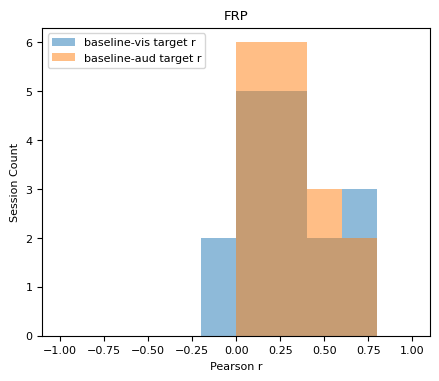

In [125]:
# decoding_utils.get_session_structure_results(baseline_decoder_results, sel_session, sel_structure, sel_unit_subsample_size, sel_time_aligned_to, sel_baseline_bin_center)
# baseline_decoder_results['structure']

sel_structure="FRP"
structure_r=baseline_stim_context_correlation_results.query('structure==@sel_structure')

xbins=np.arange(-1,1+0.1,0.2)

fig,ax=plt.subplots(1,1,figsize=(5,4))
ax.hist(structure_r['baseline_vis_target_r'], bins=xbins, alpha=0.5, label='baseline-vis target r')
ax.hist(structure_r['baseline_aud_target_r'], bins=xbins, alpha=0.5, label='baseline-aud target r')
ax.legend()

ax.set_title(f'{sel_structure}')
ax.set_xlabel('Pearson r')
ax.set_ylabel('Session Count')

In [126]:
#z-transform r values and then take the mean and sem for each structure, transform back into r, save in new table

structure_mean_sem_results={
    'structure':[],
    'baseline_vis_target_mean_r':[],
    'baseline_vis_target_sem_r':[],
    'baseline_aud_target_mean_r':[],
    'baseline_aud_target_sem_r':[],
    'n_sessions':[],
}

for sel_structure in baseline_stim_context_correlation_results['structure'].unique():
    structure_r=baseline_stim_context_correlation_results.query('structure==@sel_structure')
    n_sessions=len(structure_r)
    if n_sessions>1:
        vis_target_z=np.arctanh(structure_r['baseline_vis_target_r'])
        aud_target_z=np.arctanh(structure_r['baseline_aud_target_r'])

        vis_target_mean_z=np.nanmean(vis_target_z)
        vis_target_sem_z=stats.sem(vis_target_z, nan_policy='omit')

        aud_target_mean_z=np.nanmean(aud_target_z)
        aud_target_sem_z=stats.sem(aud_target_z, nan_policy='omit')

        structure_mean_sem_results['structure'].append(sel_structure)
        structure_mean_sem_results['baseline_vis_target_mean_r'].append(np.tanh(vis_target_mean_z))
        structure_mean_sem_results['baseline_vis_target_sem_r'].append(np.tanh(vis_target_sem_z))
        structure_mean_sem_results['baseline_aud_target_mean_r'].append(np.tanh(aud_target_mean_z))
        structure_mean_sem_results['baseline_aud_target_sem_r'].append(np.tanh(aud_target_sem_z))
        structure_mean_sem_results['n_sessions'].append(n_sessions)

    else:
        structure_mean_sem_results['structure'].append(sel_structure)
        structure_mean_sem_results['baseline_vis_target_mean_r'].append(structure_r['baseline_vis_target_r'].values[0])
        structure_mean_sem_results['baseline_vis_target_sem_r'].append(np.nan)
        structure_mean_sem_results['baseline_aud_target_mean_r'].append(structure_r['baseline_aud_target_r'].values[0])
        structure_mean_sem_results['baseline_aud_target_sem_r'].append(np.nan)
        structure_mean_sem_results['n_sessions'].append(n_sessions)

structure_mean_sem_results=pd.DataFrame(structure_mean_sem_results)

In [127]:
structure_mean_sem_results

,structure,baseline_vis_target_mean_r,baseline_vis_target_sem_r,baseline_aud_target_mean_r,baseline_aud_target_sem_r,n_sessions
0,ACAd,0.357623,0.061146,0.335657,0.046018,26
1,ACAv,0.037541,0.026195,0.110534,0.023429,22
2,APN,0.227657,0.052076,0.186469,0.081607,10
3,CA1,-0.024359,0.021480,0.034754,0.017855,41
4,CA3,0.035166,0.019725,0.056826,0.033086,24
...,...,...,...,...,...,...
126,LSv,-0.077236,NaN,-0.015392,NaN,1
127,PF,0.245874,NaN,0.390893,NaN,1
128,SUM,-0.027988,NaN,0.021958,NaN,1
129,LA,-0.022160,NaN,-0.044875,NaN,1


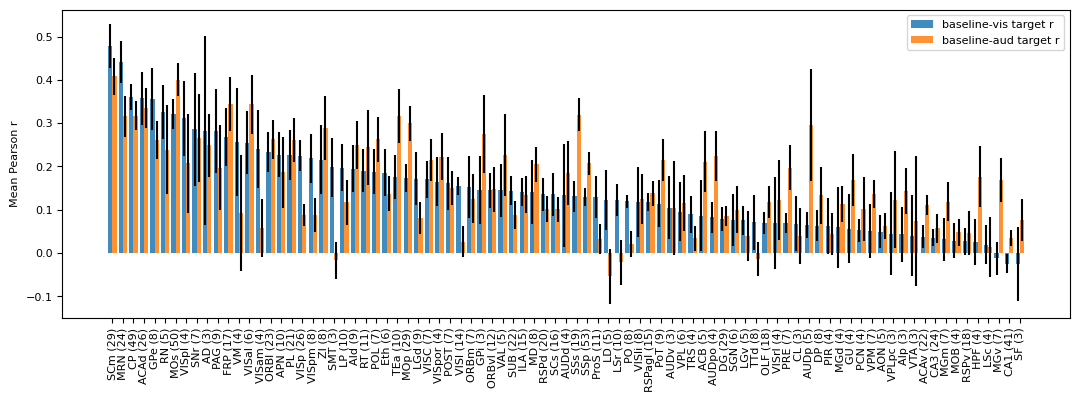

In [131]:
min_n_sessions=3
plot_data=structure_mean_sem_results.query('n_sessions>=@min_n_sessions').sort_values('baseline_vis_target_mean_r', ascending=False)

xvect=np.arange(len(plot_data))
labels=plot_data['structure'].values
for xx,ss in zip(xvect, labels):
    n_sess=plot_data.query('structure==@ss')['n_sessions'].values[0]
    plot_data.loc[plot_data['structure']==ss, 'structure']=f'{ss} ({n_sess})'

fig,ax=plt.subplots(1,1,figsize=(13,4))
ax.bar(xvect-0.2, plot_data['baseline_vis_target_mean_r'], yerr=plot_data['baseline_vis_target_sem_r'], width=0.4, alpha=0.85, label='baseline-vis target r')
ax.bar(xvect+0.2, plot_data['baseline_aud_target_mean_r'], yerr=plot_data['baseline_aud_target_sem_r'], width=0.4, alpha=0.85, label='baseline-aud target r')
ax.set_xticks(xvect)
ax.set_xticklabels(plot_data['structure'], rotation=90, ha='center')
ax.set_ylabel('Mean Pearson r')
ax.legend()
